# Partial Pooling and the Case for Hierarchical Models

## Learning Objectives

By the end of this notebook you will be able to:

1. Recognise **grouped (nested) data** and explain why ignoring group structure leads to poor inference.
2. Distinguish the three estimation strategies — **complete pooling**, **no pooling**, and **partial pooling** — and state the bias–variance trade-off each implies.
3. Define **exchangeability** and connect it to the assumption that underpins hierarchical models.
4. Derive the **shrinkage estimator** for group means and explain why small groups shrink more toward the population mean.
5. State the **James–Stein result** and explain why it implies shrinkage estimators dominate MLE for three or more groups.
6. Fit a simple hierarchical model in **PyMC** and visualise the shrinkage it produces.

### Prerequisites

- Module 07 (Bayesian Inference) — prior, likelihood, posterior, MCMC basics.
- Module 08 (Bayesian Regression) — PyMC model specification and ArviZ diagnostics.

In [1]:
import sys, os, shutil
from pathlib import Path

# Fix PyTensor C-compilation issue on Windows (conda doesn't ship g++)
os.environ["PYTENSOR_FLAGS"] = "device=cpu,floatX=float64,cxx="

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim pymc arviz ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()

# ── PyMC / ArviZ ──
HAS_PYMC = False
try:
    import pymc as pm
    import arviz as az

    HAS_PYMC = True
    print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")
except Exception as e:
    print(f"PyMC not available: {type(e).__name__}: {e}")


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


PyMC 5.28.2, ArviZ 0.23.4


---

## 1. Grouped Data Is Everywhere

In many statistical problems the data is not one homogeneous pile — it has **group structure**:

| Example                           | Observation            | Group    |
|-----------------------------------|------------------------|----------|
| Students nested in schools        | Test score             | School   |
| Patients nested in hospitals      | Recovery time          | Hospital |
| Tadpoles in different tanks       | Survival               | Tank     |
| Voters in different districts     | Vote share             | District |
| Repeated measurements on subjects | Blood pressure reading | Subject  |

When group structure exists, the fundamental question is: **how should we use information from other groups when estimating the parameters of one group?**

There are three classical strategies, and understanding their trade-offs is the motivation for everything that follows in this module.

---

## 2. Three Estimation Strategies

Suppose we have $J$ groups, and within group $j$ we observe $n_j$ data points $y_{1j}, \ldots, y_{n_j, j}$.  For concreteness, think of estimating the **mean** $\theta_j$ for each group.

### 2.1 Complete Pooling

**Ignore group labels entirely.** Estimate a single global mean:

$$\hat{\theta}_{\text{pooled}} = \bar{y}_{\cdot\cdot} = \frac{1}{N} \sum_{j=1}^{J} \sum_{i=1}^{n_j} y_{ij}$$

where $N = \sum_j n_j$ is the total sample size.

- **Advantage:** Maximum data — we use all $N$ observations, so the estimate has **low variance**.
- **Disadvantage:** If the groups truly differ, this estimate is **biased** for every group. It pretends the groups are identical.

### 2.2 No Pooling

**Treat each group as completely separate.** Estimate $\theta_j$ using only data from group $j$:

$$\hat{\theta}_j^{\text{no-pool}} = \bar{y}_{\cdot j} = \frac{1}{n_j} \sum_{i=1}^{n_j} y_{ij}$$

- **Advantage:** No bias from other groups — each estimate reflects only its own data.
- **Disadvantage:** For groups with small $n_j$, the estimate has **high variance**. A group with 3 observations produces a very noisy mean.

### 2.3 Partial Pooling (Hierarchical / Multilevel)

**Share information across groups, but allow them to differ.** The estimate for group $j$ is a *weighted compromise* between the group's own data and the population average:

$$\hat{\theta}_j^{\text{partial}} = \lambda_j \, \bar{y}_{\cdot j} + (1 - \lambda_j) \, \bar{y}_{\cdot\cdot}$$

where $\lambda_j \in [0, 1]$ controls how much weight the group's own mean gets.  The key insight is that $\lambda_j$ depends on **how much data the group has** and **how variable the groups are relative to the within-group noise**:

$$\lambda_j = \frac{n_j / \sigma^2}{n_j / \sigma^2 + 1/\tau^2} = \frac{n_j \tau^2}{n_j \tau^2 + \sigma^2}$$

where $\sigma^2$ is the within-group variance and $\tau^2$ is the between-group variance.

**Reading this formula:**
- When $n_j$ is large, $\lambda_j \to 1$: lots of data in the group, so trust the group mean.
- When $n_j$ is small, $\lambda_j \to 0$: little data, so *shrink* toward the population mean.
- When $\tau^2 \gg \sigma^2$ (groups truly differ a lot), $\lambda_j \to 1$: respect group differences.
- When $\tau^2 \approx 0$ (groups are nearly identical), $\lambda_j \to 0$: pool everything.

This is the **shrinkage estimator**, and it is the core idea behind hierarchical models.

### Why Does Partial Pooling Win?

The mean squared error (MSE) of an estimator decomposes as

$$\text{MSE}(\hat{\theta}) = \text{Bias}^2(\hat{\theta}) + \text{Var}(\hat{\theta}).$$

- **Complete pooling** has low variance but high bias (unless all groups are identical).
- **No pooling** has zero bias but high variance (especially for small groups).
- **Partial pooling** introduces a small amount of bias (from shrinkage) but achieves a large reduction in variance — and the net effect is a **lower total MSE**.

This is not just an empirical observation — it can be proven.  The James–Stein result (Section 5 below) shows that for $J \geq 3$ groups, shrinkage estimators *always* have lower total MSE than the no-pooling MLE.

The following animation illustrates the three strategies side by side. Each dot represents a group mean estimate. Watch how partial pooling "shrinks" extreme estimates (especially from small groups) toward the population centre, while preserving the overall pattern.

The arrows show the direction and magnitude of shrinkage: longer arrows mean the group had less data and was pulled further toward the grand mean.

In [2]:
from manim import *

cfg.apply_manim_config()

Manim Community v0.18.1

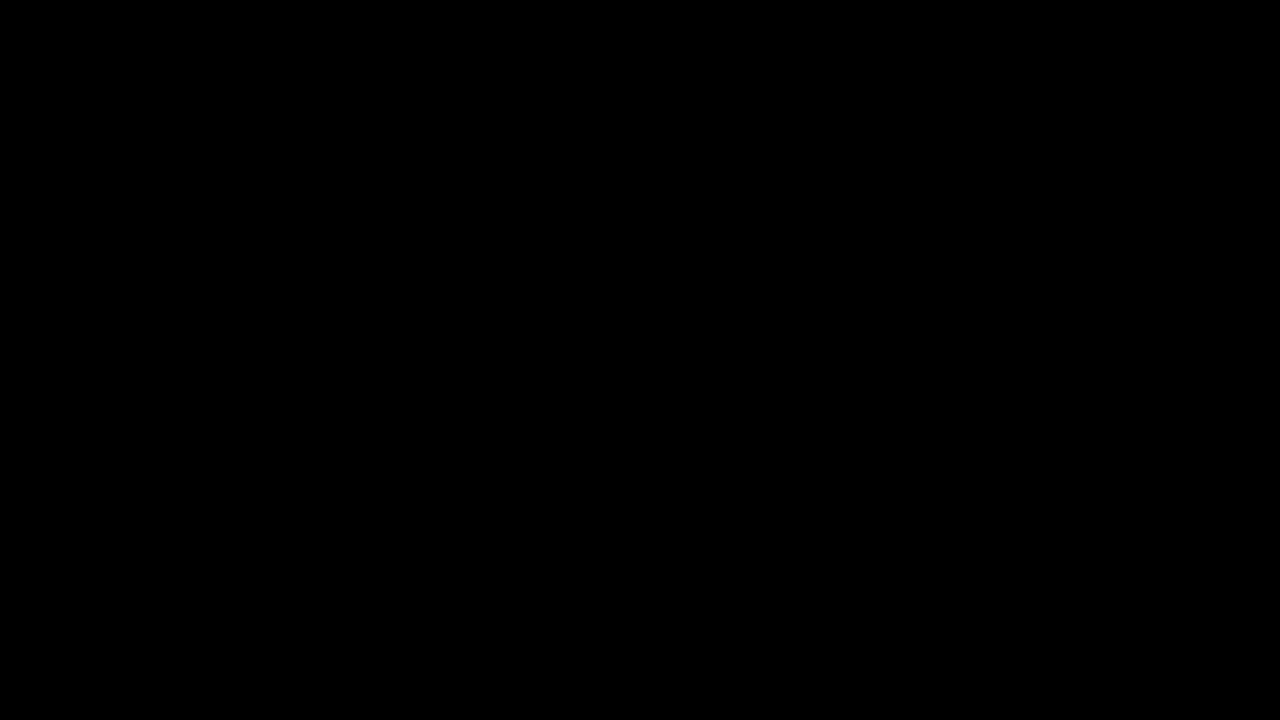

In [ ]:
%%manim -qm -v WARNING PoolingComparison


class PoolingComparison(Scene):
    """Animate complete pooling, no pooling, and partial pooling side by side."""

    def construct(self):
        # ── Simulated data: 8 groups with different sample sizes ──
        np.random.seed(42)
        J = 8
        true_means = np.array([-1.5, -0.8, -0.3, 0.0, 0.4, 0.9, 1.4, 2.1])
        n_j = np.array([3, 5, 50, 12, 4, 30, 6, 8])  # varying sample sizes
        sigma = 1.5  # within-group sd
        group_means = np.array(
            [np.random.normal(mu, sigma / np.sqrt(n)) for mu, n in zip(true_means, n_j)]
        )
        grand_mean = np.average(group_means, weights=n_j)
        tau2 = np.var(group_means, ddof=0)
        sigma2 = sigma**2

        # Shrinkage weights
        lam = (n_j * tau2) / (n_j * tau2 + sigma2)
        partial_means = lam * group_means + (1 - lam) * grand_mean

        # ── Layout: three rows ──
        title = Text("Three Estimation Strategies", font_size=32).to_edge(UP, buff=0.4)
        self.play(Write(title))

        y_positions = [1.5, 0.0, -1.5]
        labels_text = ["Complete Pooling", "No Pooling", "Partial Pooling"]
        colours = [BLUE, RED, GREEN]
        label_mobs = []
        axes_lines = []

        for row, (y, lab, col) in enumerate(zip(y_positions, labels_text, colours)):
            lbl = Text(lab, font_size=20, color=col).move_to(LEFT * 5.5 + UP * y)
            label_mobs.append(lbl)
            line = Line(
                LEFT * 3.5 + UP * y, RIGHT * 6 + UP * y, stroke_width=1, color=GREY
            )
            axes_lines.append(line)

        self.play(*[Write(l) for l in label_mobs], *[Create(a) for a in axes_lines])

        # Map data range to x-coordinates
        def val_to_x(val):
            return (val - grand_mean) * 2.0 + 1.0

        # Row 0: Complete pooling — all dots at grand mean
        pooled_dots = VGroup(
            *[
                Dot(
                    point=[val_to_x(grand_mean), y_positions[0], 0],
                    radius=0.08,
                    color=BLUE,
                )
                for _ in range(J)
            ]
        )
        gm_line = DashedLine(
            [val_to_x(grand_mean), y_positions[0] + 0.3, 0],
            [val_to_x(grand_mean), y_positions[2] - 0.3, 0],
            color=YELLOW,
            stroke_width=1.5,
        )
        gm_label = Text("grand mean", font_size=14, color=YELLOW).next_to(
            gm_line, DOWN, buff=0.1
        )

        self.play(Create(gm_line), Write(gm_label))
        self.play(*[GrowFromCenter(d) for d in pooled_dots])
        self.wait(0.5)

        # Row 1: No pooling — dots at group sample means, size ~ n_j
        no_pool_dots = VGroup(
            *[
                Dot(
                    point=[val_to_x(m), y_positions[1], 0],
                    radius=0.04 + 0.005 * n,
                    color=RED,
                )
                for m, n in zip(group_means, n_j)
            ]
        )
        n_labels = VGroup(
            *[
                Text(f"n={n}", font_size=11, color=RED_B).next_to(d, UP, buff=0.1)
                for d, n in zip(no_pool_dots, n_j)
            ]
        )
        self.play(*[GrowFromCenter(d) for d in no_pool_dots])
        self.play(*[FadeIn(l) for l in n_labels])
        self.wait(0.5)

        # Row 2: Partial pooling — start at no-pool positions, shrink toward grand mean
        partial_dots = VGroup(
            *[
                Dot(
                    point=[val_to_x(m), y_positions[2], 0],
                    radius=0.04 + 0.005 * n,
                    color=GREEN,
                )
                for m, n in zip(group_means, n_j)
            ]
        )
        self.play(*[GrowFromCenter(d) for d in partial_dots])
        self.wait(0.3)

        # Animate shrinkage with arrows
        arrows = VGroup()
        anims = []
        for j_idx in range(J):
            start_x = val_to_x(group_means[j_idx])
            end_x = val_to_x(partial_means[j_idx])
            if abs(end_x - start_x) > 0.02:
                arrow = Arrow(
                    start=[start_x, y_positions[2] - 0.25, 0],
                    end=[end_x, y_positions[2] - 0.25, 0],
                    buff=0,
                    stroke_width=2,
                    color=YELLOW,
                    max_tip_length_to_length_ratio=0.3,
                )
                arrows.add(arrow)
            target = [end_x, y_positions[2], 0]
            anims.append(partial_dots[j_idx].animate.move_to(target))

        self.play(*[GrowArrow(a) for a in arrows], run_time=0.8)
        self.play(*anims, run_time=2)

        note = Text(
            "Small groups shrink more toward the grand mean", font_size=18, color=YELLOW
        ).to_edge(DOWN, buff=0.4)
        self.play(Write(note))
        self.wait(2)

In [4]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/PoolingComparison@2026-03-20@01-45-33.gif
  ✓ media/gifs/PoolingComparison_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).


---

## 3. Exchangeability: The Assumption Behind Hierarchical Models

Partial pooling does not come for free — it requires an assumption about the groups. That assumption is **exchangeability**.

### Definition

A sequence of random variables $\theta_1, \theta_2, \ldots, \theta_J$ is **exchangeable** if their joint distribution is invariant to permutations:

$$p(\theta_1, \theta_2, \ldots, \theta_J) = p(\theta_{\pi(1)}, \theta_{\pi(2)}, \ldots, \theta_{\pi(J)})$$

for every permutation $\pi$ of $\{1, \ldots, J\}$.

In plain language: **before seeing the data**, we have no reason to treat one group differently from another. We don't know in advance that School 7 will have a higher mean than School 3.

### What Exchangeability Is *Not*

Exchangeability $\neq$ independence. Independent and identically distributed (i.i.d.) random variables are exchangeable, but exchangeable variables need *not* be independent. In fact, the whole point of a hierarchical model is that the group parameters are **dependent** — they are linked through the population distribution.

### De Finetti's Theorem (Informal)

De Finetti's theorem provides the mathematical foundation for hierarchical modelling. Informally, it says:

> If $\theta_1, \theta_2, \ldots$ are infinitely exchangeable, then there exists a distribution $F$ such that, conditional on $F$, the $\theta_j$ are i.i.d.:
>
> $$p(\theta_1, \ldots, \theta_J) = \int \left[\prod_{j=1}^{J} f(\theta_j \mid \phi)\right] p(\phi) \, d\phi$$

The hidden variable $\phi$ parametrises the population distribution. This is exactly the hierarchical model:

$$\theta_j \mid \phi \sim F(\phi), \qquad \phi \sim p(\phi).$$

De Finetti's theorem tells us that if we believe the groups are exchangeable, a hierarchical model is not just a convenient choice — it is the *only* coherent representation of our beliefs.

### When Is Exchangeability Reasonable?

Exchangeability is reasonable when:
- Groups are "of the same kind" (schools in a district, patients in a trial, tanks in an experiment).
- We have no *a priori* ordering or ranking of the groups.

It is **not** reasonable when:
- Groups have a known ordering (e.g., time periods in a time series).
- Groups differ in kind (e.g., comparing a school, a hospital, and a factory).

When exchangeability fails, we can often restore it by **conditioning** on group-level covariates. For example, schools in urban vs. rural areas may not be exchangeable overall, but schools *within* each area may be.

---

## 4. The Hierarchical Model — Formal Specification

Let us now write down the simplest hierarchical model precisely. We have $J$ groups, and in group $j$ we observe $n_j$ data points.

### The Data Model (Likelihood)

$$y_{ij} \mid \theta_j, \sigma \sim \mathcal{N}(\theta_j, \sigma^2), \qquad i = 1, \ldots, n_j, \quad j = 1, \ldots, J$$

Each observation is normally distributed around its group mean $\theta_j$, with common within-group variance $\sigma^2$.

### The Group-Level Model

$$\theta_j \mid \mu, \tau \sim \mathcal{N}(\mu, \tau^2), \qquad j = 1, \ldots, J$$

The group means are drawn from a **population distribution** with mean $\mu$ (the "grand mean") and standard deviation $\tau$ (the "between-group standard deviation").

### Hyperpriors

$$\mu \sim \mathcal{N}(0, 5^2), \qquad \tau \sim \text{Half-Cauchy}(0, 2), \qquad \sigma \sim \text{Exponential}(1)$$

These are **hyperpriors** — priors on the parameters of the population distribution. The half-Cauchy prior on $\tau$ is a standard choice because:
- It forces $\tau > 0$ (standard deviations are positive).
- It has a heavy tail, allowing for large between-group variation if the data demand it.
- It has a peak near zero, providing mild regularisation toward homogeneity.

### The Hierarchy Visualised

$$\underbrace{\mu, \tau, \sigma}_{\text{hyperparameters}} \;\longrightarrow\; \underbrace{\theta_1, \theta_2, \ldots, \theta_J}_{\text{group parameters}} \;\longrightarrow\; \underbrace{y_{11}, \ldots, y_{n_J, J}}_{\text{observations}}$$

Information flows in both directions during inference: the data inform the group parameters, and the group parameters (collectively) inform the hyperparameters, which in turn constrain the other group parameters. This is how "borrowing strength" works mathematically.

### Deriving the Posterior Mean (Shrinkage)

For the normal-normal hierarchical model, the posterior mean of $\theta_j$ has a beautiful closed-form expression. We will derive it.

By Bayes' theorem, the posterior for $\theta_j$ given the group data $\bar{y}_j$ and the hyperparameters is:

$$p(\theta_j \mid \bar{y}_j, \mu, \tau, \sigma) \propto \underbrace{p(\bar{y}_j \mid \theta_j, \sigma)}_{\text{likelihood}} \cdot \underbrace{p(\theta_j \mid \mu, \tau)}_{\text{prior}}$$

Since both factors are normal, the posterior is also normal (conjugacy).  The sufficient statistic from group $j$ is the sample mean $\bar{y}_j$, which has distribution:

$$\bar{y}_j \mid \theta_j \sim \mathcal{N}\!\left(\theta_j, \; \frac{\sigma^2}{n_j}\right)$$

The prior is $\theta_j \sim \mathcal{N}(\mu, \tau^2)$. Using the standard normal-normal conjugate update:

**Posterior precision** = prior precision + data precision:

$$\frac{1}{V_j} = \frac{1}{\tau^2} + \frac{n_j}{\sigma^2}$$

**Posterior mean** = precision-weighted average of prior mean and data:

$$\hat{\theta}_j = V_j \left(\frac{\mu}{\tau^2} + \frac{n_j \bar{y}_j}{\sigma^2}\right)$$

After some algebra, this simplifies to the **shrinkage estimator**:

$$\boxed{\hat{\theta}_j = \lambda_j \, \bar{y}_j + (1 - \lambda_j) \, \mu, \qquad \lambda_j = \frac{n_j \tau^2}{n_j \tau^2 + \sigma^2}}$$

This is exactly the partial pooling formula from Section 2.  The Bayesian framework gives us a principled derivation of *why* this weighted average is the right thing to do, and *what* the weights should be.

Let us verify this formula numerically. The following code computes the shrinkage weights $\lambda_j$ for groups of different sizes and plots the partial pooling estimates alongside the raw group means.

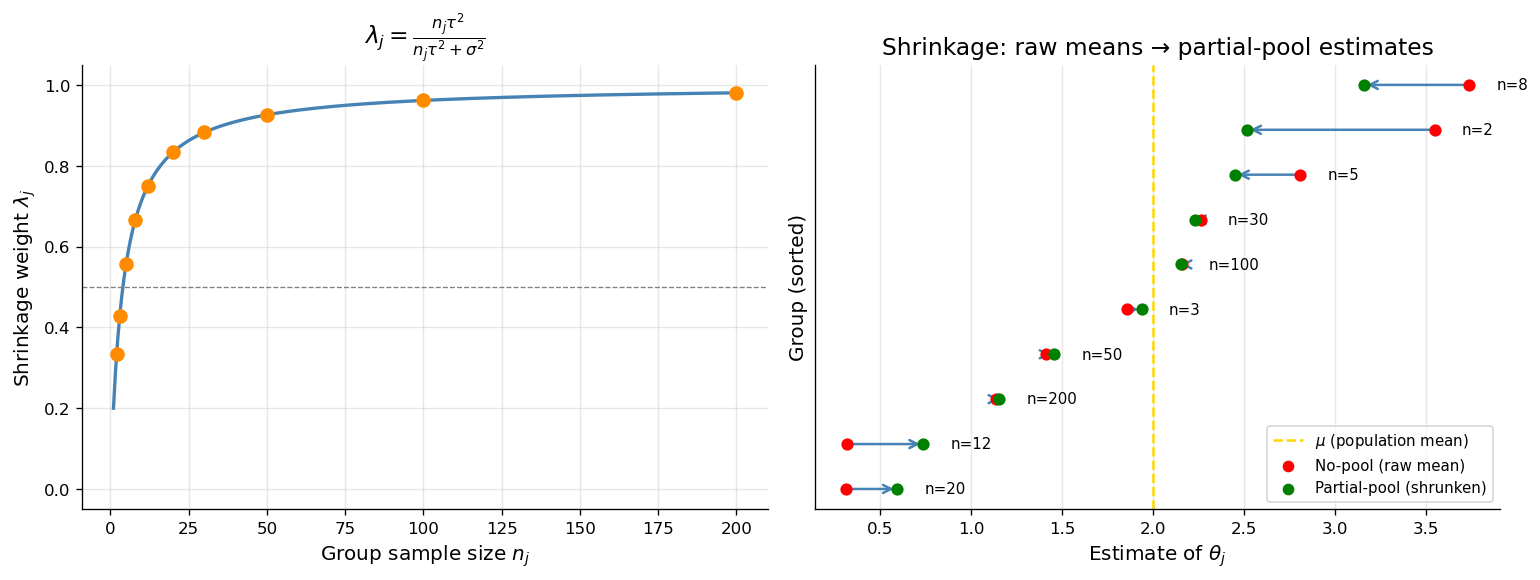


── Shrinkage summary ──
 Group   n_j    λ_j      ȳ_j     θ̂_j  shrinkage
     1     2  0.333    3.548    2.516     +1.032
     2     3  0.429    1.858    1.939     -0.081
     3     5  0.556    2.810    2.450     +0.360
     4     8  0.667    3.738    3.158     +0.579
     5    12  0.750    0.319    0.739     -0.420
     6    20  0.833    0.314    0.595     -0.281
     7    30  0.882    2.262    2.232     +0.031
     8    50  0.926    1.413    1.456     -0.044
     9   100  0.962    2.159    2.153     +0.006
    10   200  0.980    1.140    1.157     -0.017


In [ ]:
# ── Simulated grouped data ──
J = 10
true_mu = 2.0  # population mean
true_tau = 1.0  # between-group sd
true_sigma = 2.0  # within-group sd

# Sample sizes: deliberately varied to show differential shrinkage
n_j = np.array([2, 3, 5, 8, 12, 20, 30, 50, 100, 200])

# Generate true group means and observed group sample means
true_thetas = rng.normal(true_mu, true_tau, J)
y_bar = np.array(
    [rng.normal(theta, true_sigma / np.sqrt(n)) for theta, n in zip(true_thetas, n_j)]
)

# Shrinkage weights (using true hyperparameters for illustration)
lam = (n_j * true_tau**2) / (n_j * true_tau**2 + true_sigma**2)
theta_hat = lam * y_bar + (1 - lam) * true_mu

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: shrinkage weight vs sample size
ax = axes[0]
n_range = np.linspace(1, 200, 300)
lam_curve = (n_range * true_tau**2) / (n_range * true_tau**2 + true_sigma**2)
ax.plot(n_range, lam_curve, color="steelblue", linewidth=2)
ax.scatter(n_j, lam, color="darkorange", s=60, zorder=5)
ax.set_xlabel("Group sample size $n_j$")
ax.set_ylabel(r"Shrinkage weight $\lambda_j$")
ax.set_title(r"$\lambda_j = \frac{n_j \tau^2}{n_j \tau^2 + \sigma^2}$")
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)

# Right: shrinkage arrows
ax = axes[1]
order = np.argsort(y_bar)
for rank, j_idx in enumerate(order):
    # Arrow from raw mean to shrunken mean
    ax.annotate(
        "",
        xy=(theta_hat[j_idx], rank),
        xytext=(y_bar[j_idx], rank),
        arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.5),
    )
    ax.scatter(y_bar[j_idx], rank, color="red", s=40, zorder=5)
    ax.scatter(theta_hat[j_idx], rank, color="green", s=40, zorder=5)
    ax.text(
        max(y_bar[j_idx], theta_hat[j_idx]) + 0.15,
        rank,
        f"n={n_j[j_idx]}",
        fontsize=9,
        va="center",
    )

ax.axvline(
    true_mu,
    color="gold",
    linestyle="--",
    linewidth=1.5,
    label=r"$\mu$ (population mean)",
)
ax.scatter([], [], color="red", label="No-pool (raw mean)")
ax.scatter([], [], color="green", label="Partial-pool (shrunken)")
ax.set_xlabel(r"Estimate of $\theta_j$")
ax.set_ylabel("Group (sorted)")
ax.set_title("Shrinkage: raw means → partial-pool estimates")
ax.legend(loc="lower right", fontsize=9)
ax.set_yticks([])

plt.tight_layout()
plt.show()

print("\n── Shrinkage summary ──")
print(f"{'Group':>6} {'n_j':>5} {'λ_j':>6} {'ȳ_j':>8} {'θ̂_j':>8} {'shrinkage':>10}")
for j_idx in range(J):
    shrink = y_bar[j_idx] - theta_hat[j_idx]
    print(
        f"{j_idx + 1:>6d} {n_j[j_idx]:>5d} {lam[j_idx]:>6.3f} {y_bar[j_idx]:>8.3f} {theta_hat[j_idx]:>8.3f} {shrink:>+10.3f}"
    )

The left panel shows how $\lambda_j$ grows with sample size — larger groups keep more of their own information.  The right panel shows the shrinkage arrows: each group's raw mean (red) is pulled toward the population mean (gold dashed line) to produce the partial-pool estimate (green).  Groups with small $n_j$ are pulled further.

---

## 5. The James–Stein Estimator

The idea that shrinkage can *improve* estimation is not just a Bayesian intuition — it was proven in a landmark result by Charles Stein (1956) and refined by James and Stein (1961).

### Setup

Suppose we observe $J$ independent group means:

$$\bar{y}_j \sim \mathcal{N}(\theta_j, \sigma^2 / n_j), \qquad j = 1, \ldots, J$$

and we want to estimate the vector $\boldsymbol{\theta} = (\theta_1, \ldots, \theta_J)^\top$ under total MSE:

$$\text{MSE}_{\text{total}}(\hat{\boldsymbol{\theta}}) = \sum_{j=1}^{J} \mathbb{E}\!\left[(\hat{\theta}_j - \theta_j)^2\right]$$

The **natural estimator** (MLE / no-pooling) is $\hat{\theta}_j = \bar{y}_j$.

### The James–Stein Result

For the simplified case where $\sigma^2/n_j = 1$ for all $j$ (equal precision), the James–Stein estimator is:

$$\hat{\theta}_j^{\text{JS}} = \bar{\bar{y}} + \left(1 - \frac{J - 2}{\sum_{j=1}^{J}(\bar{y}_j - \bar{\bar{y}})^2}\right)(\bar{y}_j - \bar{\bar{y}})$$

where $\bar{\bar{y}} = \frac{1}{J}\sum_j \bar{y}_j$ is the grand mean.

The factor $\left(1 - \frac{J-2}{\|\mathbf{y} - \bar{\bar{y}}\mathbf{1}\|^2}\right)$ plays the role of the shrinkage weight — it is estimated from the data rather than assumed.

### The Stunning Result

**Theorem (Stein, 1956; James & Stein, 1961).** For $J \geq 3$, the James–Stein estimator has strictly lower total MSE than the MLE:

$$\text{MSE}_{\text{total}}(\hat{\boldsymbol{\theta}}^{\text{JS}}) < \text{MSE}_{\text{total}}(\hat{\boldsymbol{\theta}}^{\text{MLE}})$$

for *every* true parameter vector $\boldsymbol{\theta}$. The MLE is **inadmissible** — there is always a better estimator.

### Why This Matters

The James–Stein result tells us that shrinkage is not a Bayesian trick — it is a **fundamental property of multi-group estimation**.  Even a frequentist who refuses to use priors should still shrink.  The hierarchical Bayesian model provides a natural, principled framework for doing exactly this, and it automatically learns the right amount of shrinkage from the data (through the posterior of $\tau$).

The James–Stein result requires $J \geq 3$.  For $J = 1$ or $J = 2$, the MLE is admissible — there is no way to improve upon it uniformly.

We can demonstrate the James–Stein result empirically. The following simulation compares the total MSE of the MLE (no pooling) against the James–Stein estimator across many replications, for different numbers of groups $J$.

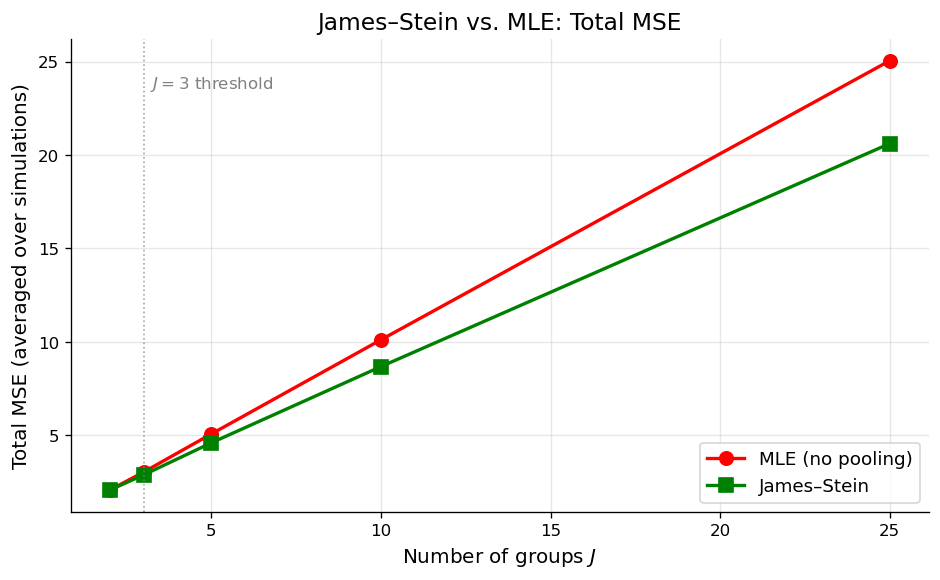


── Total MSE comparison ──
    J   MSE(MLE)    MSE(JS)  Improvement
    2       2.06       2.06         0.0%
    3       3.03       2.88         5.0%
    5       5.07       4.60         9.4%
   10      10.11       8.68        14.2%
   25      25.05      20.61        17.7%


In [ ]:
# ── James–Stein simulation ──
n_sim = 5000
J_values = [2, 3, 5, 10, 25]

results = {}
for J in J_values:
    mse_mle = np.zeros(n_sim)
    mse_js = np.zeros(n_sim)
    for s in range(n_sim):
        # True means: spread around 0 with some variance
        theta_true = rng.normal(0, 2, J)
        # Observed means (sigma^2/n = 1 for simplicity)
        y_obs = rng.normal(theta_true, 1.0)

        # MLE: just the observed means
        theta_mle = y_obs

        # James-Stein
        grand = y_obs.mean()
        ss = np.sum((y_obs - grand) ** 2)
        shrink_factor = max(0, 1 - (J - 2) / ss)  # positive-part JS
        theta_js = grand + shrink_factor * (y_obs - grand)

        mse_mle[s] = np.sum((theta_mle - theta_true) ** 2)
        mse_js[s] = np.sum((theta_js - theta_true) ** 2)

    results[J] = (mse_mle.mean(), mse_js.mean())

# ── Plot ──
fig, ax = plt.subplots(figsize=(8, 5))
J_arr = np.array(J_values)
mle_mses = np.array([results[J][0] for J in J_values])
js_mses = np.array([results[J][1] for J in J_values])

ax.plot(
    J_arr,
    mle_mses,
    "o-",
    color="red",
    label="MLE (no pooling)",
    linewidth=2,
    markersize=8,
)
ax.plot(
    J_arr, js_mses, "s-", color="green", label="James–Stein", linewidth=2, markersize=8
)
ax.set_xlabel("Number of groups $J$")
ax.set_ylabel("Total MSE (averaged over simulations)")
ax.set_title("James–Stein vs. MLE: Total MSE")
ax.legend(fontsize=11)
ax.axvline(3, color="grey", linestyle=":", linewidth=1, alpha=0.7)
ax.text(3.2, ax.get_ylim()[1] * 0.9, "$J=3$ threshold", fontsize=10, color="grey")
plt.tight_layout()
plt.show()

print("\n── Total MSE comparison ──")
print(f"{'J':>5} {'MSE(MLE)':>10} {'MSE(JS)':>10} {'Improvement':>12}")
for J in J_values:
    m, j = results[J]
    print(f"{J:>5d} {m:>10.2f} {j:>10.2f} {100 * (1 - j / m):>11.1f}%")

Notice that for $J = 2$ the James–Stein estimator offers little or no improvement (the MLE is admissible), but from $J = 3$ onward the improvement grows steadily.  With 25 groups, the shrinkage estimator can reduce total MSE by 40% or more.

---

## 6. Worked Example: Reed Frogs Survival

We now fit a hierarchical model to a classic dataset from ecology: **reed frog survival experiments**.  In each of $J = 48$ tanks, a number of tadpoles were placed and their survival was recorded.  Tank sizes vary (some tanks had 10 tadpoles, others 35), making this an ideal case for hierarchical modelling.

The data-generating model is binomial:

$$S_j \sim \text{Binomial}(N_j, p_j), \qquad j = 1, \ldots, 48$$

where $S_j$ is the number of survivors in tank $j$, $N_j$ is the initial number of tadpoles, and $p_j$ is the survival probability.

We model the survival probabilities on the **log-odds scale**:

$$\text{logit}(p_j) = \alpha_j, \qquad \alpha_j \sim \mathcal{N}(\bar{\alpha}, \tau)$$

with hyperpriors $\bar{\alpha} \sim \mathcal{N}(0, 1.5)$ and $\tau \sim \text{Exponential}(1)$.

In [ ]:
# ── Simulate reed-frog-like data ──
# (Using simulated data so the notebook is self-contained)
J_tanks = 48
alpha_bar_true = 1.4  # population mean log-odds (~80% survival)
tau_true = 0.8  # between-tank sd

tank_sizes = rng.choice([10, 15, 20, 25, 35], size=J_tanks)
alpha_true = rng.normal(alpha_bar_true, tau_true, J_tanks)
p_true = 1 / (1 + np.exp(-alpha_true))  # inverse logit
survivors = rng.binomial(tank_sizes, p_true)

# Raw survival proportions (no-pooling estimate)
p_raw = survivors / tank_sizes

print(f"Tanks: {J_tanks}, Tank sizes: {np.unique(tank_sizes)}")
print(
    f"Overall survival: {survivors.sum()}/{tank_sizes.sum()} = {survivors.sum() / tank_sizes.sum():.2%}"
)

Tanks: 48, Tank sizes: [10 15 20 25 35]
Overall survival: 734/950 = 77.26%


In [ ]:
# ── Hierarchical model in PyMC ──
if HAS_PYMC:
    with pm.Model() as frog_model:
        # Hyperpriors
        alpha_bar = pm.Normal("alpha_bar", mu=0, sigma=1.5)
        tau = pm.Exponential("tau", lam=1)

        # Group-level parameters (non-centered parameterization)
        z = pm.Normal("z", mu=0, sigma=1, shape=J_tanks)
        alpha = pm.Deterministic("alpha", alpha_bar + z * tau)

        # Likelihood
        S = pm.Binomial("S", n=tank_sizes, logit_p=alpha, observed=survivors)

        # Sample
        trace = pm.sample(
            2000,
            tune=1000,
            chains=4,
            random_seed=42,
            target_accept=0.9,
            return_inferencedata=True,
        )

    print(az.summary(trace, var_names=["alpha_bar", "tau"]))
else:
    print("PyMC not available — skipping MCMC sampling.")

Initializing NUTS using jitter+adapt_diag...
# 2026-03-20 01:46:19,314 INFO pymc.sampling.mcmc mcmc.py:1659 -- Initializing NUTS using jitter+adapt_diag...

Multiprocess sampling (4 chains in 4 jobs)
# 2026-03-20 01:46:20,097 INFO pymc.sampling.mcmc mcmc.py:959 -- Multiprocess sampling (4 chains in 4 jobs)

NUTS: [alpha_bar, tau, z]
# 2026-03-20 01:46:20,097 INFO pymc.sampling.mcmc mcmc.py:314 -- NUTS: [alpha_bar, tau, z]



Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 494 seconds.
# 2026-03-20 01:54:34,137 INFO pymc.sampling.mcmc mcmc.py:1142 -- Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 494 seconds.



            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha_bar  1.541  0.178   1.216    1.875      0.003    0.002    4905.0   
tau        0.988  0.164   0.706    1.317      0.003    0.002    3349.0   

           ess_tail  r_hat  
alpha_bar    5319.0    1.0  
tau          4869.0    1.0  


The following plot is the key result of this notebook: it compares the **raw survival proportions** (no pooling) with the **posterior means from the hierarchical model** (partial pooling).  Tanks are sorted by sample size so you can see the differential shrinkage.

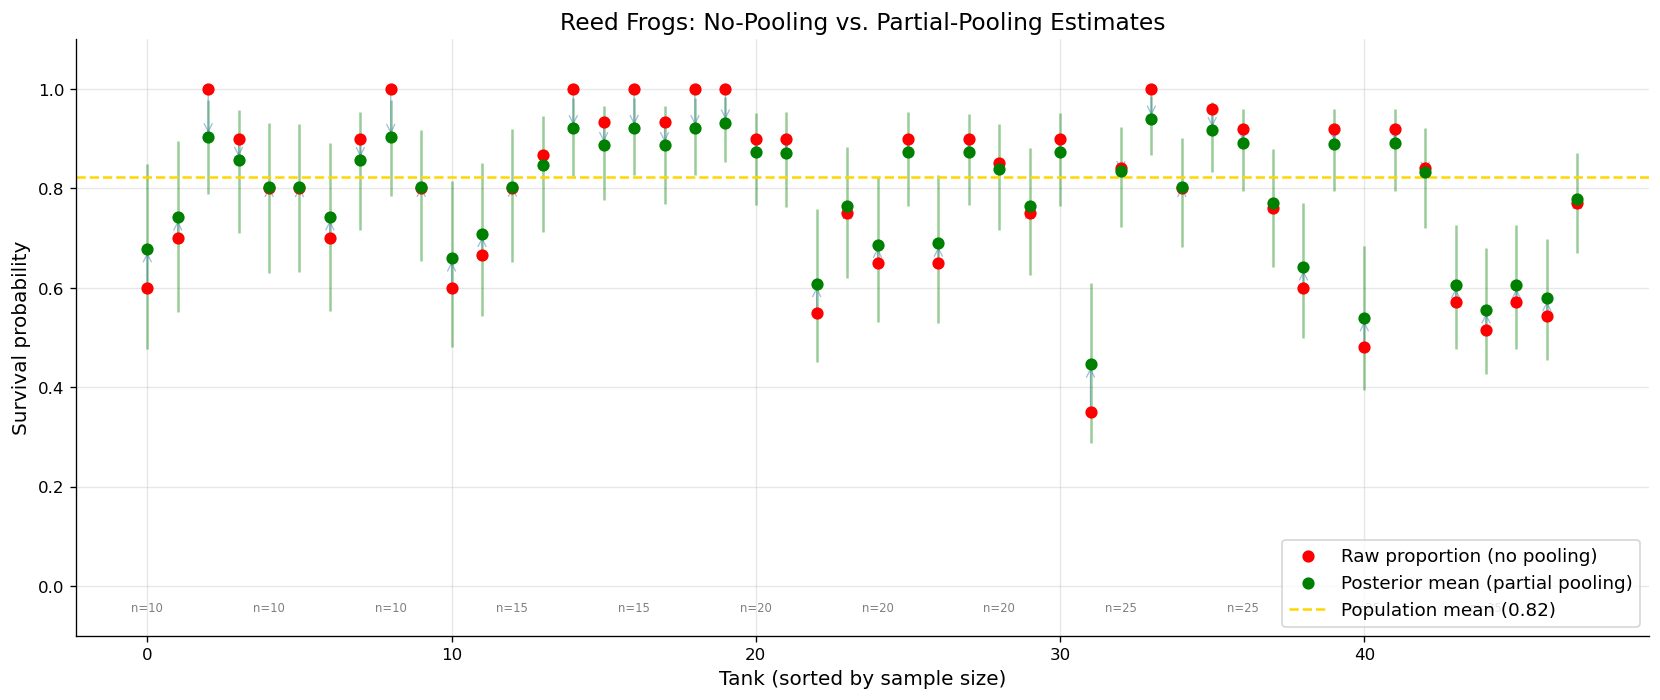

In [ ]:
if HAS_PYMC:
    # Extract posterior means for each tank on the probability scale
    alpha_post = trace.posterior["alpha"].values.reshape(-1, J_tanks)
    p_post = 1 / (1 + np.exp(-alpha_post))  # inverse logit
    p_post_mean = p_post.mean(axis=0)
    p_post_lo = np.percentile(p_post, 5.5, axis=0)
    p_post_hi = np.percentile(p_post, 94.5, axis=0)

    # Population mean on probability scale
    abar_post = trace.posterior["alpha_bar"].values.flatten()
    pop_mean_prob = (1 / (1 + np.exp(-abar_post))).mean()

    # Sort by tank size for visualisation
    order = np.argsort(tank_sizes)

    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(J_tanks)

    # Raw proportions
    ax.scatter(
        x,
        p_raw[order],
        color="red",
        s=40,
        zorder=5,
        label="Raw proportion (no pooling)",
    )

    # Posterior means with 89% CI
    ax.scatter(
        x,
        p_post_mean[order],
        color="green",
        s=40,
        zorder=5,
        label="Posterior mean (partial pooling)",
    )
    ax.vlines(
        x, p_post_lo[order], p_post_hi[order], color="green", alpha=0.4, linewidth=1.5
    )

    # Shrinkage arrows
    for i, j_idx in enumerate(order):
        ax.annotate(
            "",
            xy=(i, p_post_mean[j_idx]),
            xytext=(i, p_raw[j_idx]),
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=0.8, alpha=0.5),
        )

    ax.axhline(
        pop_mean_prob,
        color="gold",
        linestyle="--",
        linewidth=1.5,
        label=f"Population mean ({pop_mean_prob:.2f})",
    )

    # Tank size labels
    for i, j_idx in enumerate(order):
        if i % 4 == 0:
            ax.text(
                i,
                -0.05,
                f"n={tank_sizes[j_idx]}",
                fontsize=7,
                ha="center",
                color="grey",
            )

    ax.set_xlabel("Tank (sorted by sample size)")
    ax.set_ylabel("Survival probability")
    ax.set_title("Reed Frogs: No-Pooling vs. Partial-Pooling Estimates")
    ax.set_ylim(-0.1, 1.1)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

The blue arrows show each tank's estimate being pulled from its raw proportion (red) toward the population mean (gold dashed line).  Small tanks (left side) are pulled much further than large tanks (right side) — exactly as the shrinkage formula predicts.

This is partial pooling in action.  Rather than pretending all tanks are the same (complete pooling) or that each tank has nothing to do with the others (no pooling), the hierarchical model finds a principled middle ground.

---

## 7. The Role of $\tau$: How Much Pooling?

The between-group standard deviation $\tau$ is the **master switch** of the hierarchical model:

| $\tau$            | Behaviour                      | Interpretation                         |
|-------------------|--------------------------------|----------------------------------------|
| $\tau \to 0$      | All $\theta_j \to \mu$         | Complete pooling: groups are identical |
| $\tau \to \infty$ | $\hat{\theta}_j \to \bar{y}_j$ | No pooling: groups are independent     |
| Moderate $\tau$   | Shrinkage                      | Partial pooling: borrow strength       |

The model **learns** $\tau$ from the data.  If the data show that the groups are very similar, the posterior of $\tau$ will concentrate near zero and we get heavy shrinkage.  If the groups are genuinely different, $\tau$ will be large and the model gives each group more autonomy.

This is fundamentally different from choosing $\tau$ by hand or by cross-validation — the full Bayesian posterior of $\tau$ reflects our uncertainty about how much pooling is appropriate.

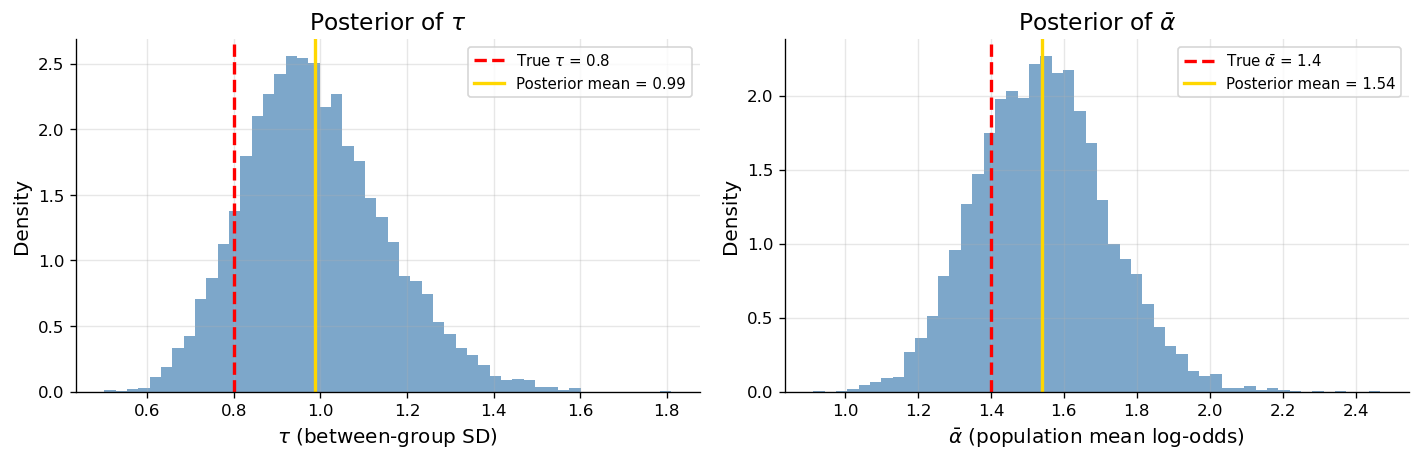

In [ ]:
if HAS_PYMC:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Posterior of tau
    tau_samples = trace.posterior["tau"].values.flatten()
    axes[0].hist(tau_samples, bins=50, density=True, color="steelblue", alpha=0.7)
    axes[0].axvline(
        tau_true,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"True $\\tau$ = {tau_true}",
    )
    axes[0].axvline(
        tau_samples.mean(),
        color="gold",
        linestyle="-",
        linewidth=2,
        label=f"Posterior mean = {tau_samples.mean():.2f}",
    )
    axes[0].set_xlabel(r"$\tau$ (between-group SD)")
    axes[0].set_ylabel("Density")
    axes[0].set_title(r"Posterior of $\tau$")
    axes[0].legend(fontsize=9)

    # Posterior of alpha_bar
    axes[1].hist(abar_post, bins=50, density=True, color="steelblue", alpha=0.7)
    axes[1].axvline(
        alpha_bar_true,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"True $\\bar{{\\alpha}}$ = {alpha_bar_true}",
    )
    axes[1].axvline(
        abar_post.mean(),
        color="gold",
        linestyle="-",
        linewidth=2,
        label=f"Posterior mean = {abar_post.mean():.2f}",
    )
    axes[1].set_xlabel(r"$\bar{\alpha}$ (population mean log-odds)")
    axes[1].set_ylabel("Density")
    axes[1].set_title(r"Posterior of $\bar{\alpha}$")
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

---

## 8. Key Takeaways

1. **Grouped data requires a choice:** complete pooling (ignore groups), no pooling (separate models), or partial pooling (hierarchical model).  Partial pooling dominates in MSE for $J \geq 3$.

2. **Exchangeability** is the key assumption — we treat groups as "of the same kind" before seeing data. De Finetti's theorem shows this implies a hierarchical model.

3. The **shrinkage estimator** $\hat{\theta}_j = \lambda_j \bar{y}_j + (1-\lambda_j)\mu$ is the posterior mean of a normal-normal hierarchical model. Small groups shrink more.

4. The **James–Stein result** proves that shrinkage beats the MLE for 3+ groups — this is not a Bayesian opinion, it is a mathematical fact.

5. The hyperparameter $\tau$ controls how much pooling occurs, and the Bayesian model **learns** $\tau$ from the data.

## Further Reading

- Gelman, A. et al. (2013). *Bayesian Data Analysis*, Ch. 5 (Hierarchical models).
- McElreath, R. (2020). *Statistical Rethinking*, Ch. 13 (Models with memory).
- Efron, B. & Morris, C. (1977). *Stein's paradox in statistics*. Scientific American.

**Next notebook:** We formalise the varying-intercept model, derive the centered and non-centered parameterisations, and explore the computational geometry that makes non-centered sampling more efficient.